In [1]:
import pandas as pd
df = pd.read_csv('train.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

In [2]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [4]:
#df["u-g"] = df["u"] - df["g"]
#df["u-r"] = df["u"] - df["r"]
#df["u-i"] = df["u"] - df["i"]
#df["u-z"] = df["u"] - df["z"]
#df["u*g"] = df["u"] * df["g"]
#df["u*r"] = df["u"] * df["r"]
#df["u*i"] = df["u"] * df["i"]
#df["u*z"] = df["u"] * df["z"]

In [5]:
df_float = df.select_dtypes(include="float").columns
df[df_float].corr()

,alpha,delta,u,g,r,i,z,redshift
alpha,1.000000,0.143541,-0.017242,-0.037731,-0.037830,-0.029333,-0.024583,0.007989
delta,0.143541,1.000000,-0.026860,-0.008386,-0.004395,0.002088,0.003347,0.053763
u,-0.017242,-0.026860,1.000000,0.826880,0.659410,0.521811,0.443923,0.078903
g,-0.037731,-0.008386,0.826880,1.000000,0.912066,0.805020,0.731737,0.237447
r,-0.037830,-0.004395,0.659410,0.912066,1.000000,0.953550,0.913341,0.390989
i,-0.029333,0.002088,0.521811,0.805020,0.953550,1.000000,0.968715,0.466575
z,-0.024583,0.003347,0.443923,0.731737,0.913341,0.968715,1.000000,0.480860
redshift,0.007989,0.053763,0.078903,0.237447,0.390989,0.466575,0.480860,1.000000


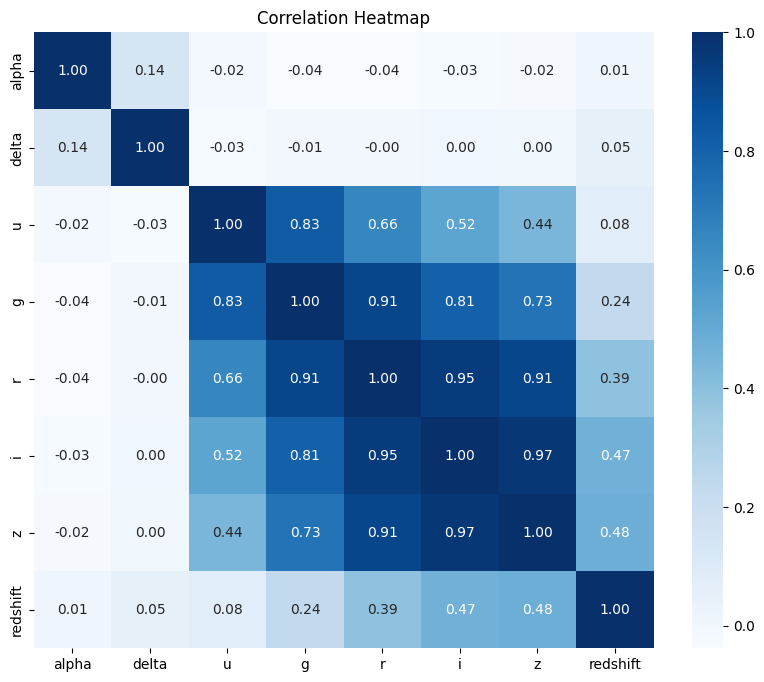

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8)) # グラフのサイズ調整
sns.heatmap(df[df_float].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
test = pd.read_csv("test.csv")

X = df.drop(["class","id"],axis=1)
y = df["class"]

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
obj_cols = ["spectral_type","galaxy_population"]
for col in obj_cols:
    X[col] = le.fit_transform(X[col])

In [9]:
X.dtypes

alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type          int64
galaxy_population      int64
dtype: object

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier(random_state=42)
model.fit(X,y)

In [ ]:
import matplotlib.pyplot as plt
# 重要度を取得
importances = pd.Series(model.feature_importances_, index=X.columns)
# 重要度が高い順に並び替えてグラフ化
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
# モデルを使って予測させる
y_pred = model.predict(X)

# 予測結果と正解を比較する
score = accuracy_score(y, y_pred)

print(f"モデルの精度 (Accuracy): {score:.4f}")